# Cetacean Detection — Model vs Expert Comparison (Harrapatu)

Compares model predictions (5-second segments) against expert annotations (5-minute WAV files).

### Key differences from the ARBAS notebook
- **Expert format**: instead of PAMGuard vote counts per 1-min WAV, the expert CSV (`expert_detections.csv`) contains only **positive rows** (T. truncatus = SI). All intervals absent from that CSV are treated as expert-negative. The expert only labelled *Tursiops truncatus* — so evaluation is at the **cetacean-detection level**, not per-species.
- **Join key**: expert WAVs use recorders `9488/9489`, model WAVs use `9488/9489/6338`. Matching is on the **timestamp interval** (`YYMMDDHHMMSS` token, position 1 in the dotted filename), not the WAV name directly.
- **Dual hydrophones**: both expert and model may have two recorders per 5-min interval. An interval is considered **expert-positive** if *either* hydrophone recorded SI; **model-positive** if any segment across *either* recorder in that interval fires a non-background consensus label.
- **Segmented vs interval format**: for expert rows with `seg_start_s`/`seg_end_s` (files L1–L3), the detection is still collapsed to interval level for this evaluation (future: sub-interval matching).

### Three prediction strategies (same MLP, different post-hoc decoding)
| Strategy | How it decides |
|---|---|
| `argmax` | plain softmax argmax |
| `vec` | per-class `w·logit + b`, inv-freq weighted |
| `pr` | argmax among species clearing F1-optimal threshold, else background |

### Consensus (`pred_consensus`)
All three agree → that label; else `'uncertain'` (treated as non-detection).

In [1]:
# ── 0. Imports & paths ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── EDIT THESE ───────────────────────────────────────────────────────────────
MY_PREDICTIONS_CSV = r"/data2/mromaniuc/cet-det/inference/inference_harrapatu/predictions/harrapatu_predictions_l4.csv"
EXPERT_CSV         = r"/data2/mromaniuc/cet-det/inference/inference_harrapatu/comparison/expert_detections.csv"
SPECTROGRAM_DIR    = r"/data2/mromaniuc/cet-det/inference/inference_harrapatu/spectrograms"
OUTPUT_CSV         = "harrapatu_comparison_5min_v1.csv"
# ─────────────────────────────────────────────────────────────────────────────

def normalise_wav_name(x):
    """Return just 'XXXX.wav' from any path, Windows or POSIX, with cleanup."""
    if pd.isna(x):
        return None
    s = str(x).strip().strip('"').strip("'")
    s = s.replace('\\\\', '/').replace('\\', '/')
    s = s.split('/')[-1]
    s = s.strip().lower()
    if not s.endswith('.wav'):
        s = s + '.wav'
    return s

def interval_from_wav(wav_name):
    """Extract the YYMMDDHHMMSS timestamp token (position 1 in dotted name).

    '9488.251007005000.wav' -> '251007005000'
    Works on raw paths too (normalise_wav_name is applied first).
    """
    if pd.isna(wav_name):
        return None
    base = normalise_wav_name(wav_name)
    parts = base.split('.')
    return parts[1] if len(parts) >= 2 else None

print("Config loaded.  Self-test of interval_from_wav:")
for t in ['9488.251007005000.wav', '6338.251010055958.wav',
          r'/datos/silvia/Harrapatu_2025/6338/6338.251010055958.wav']:
    print(f"  {t!r:60s} -> {interval_from_wav(t)!r}")

Config loaded.  Self-test of interval_from_wav:
  '9488.251007005000.wav'                                      -> '251007005000'
  '6338.251010055958.wav'                                      -> '251010055958'
  '/datos/silvia/Harrapatu_2025/6338/6338.251010055958.wav'    -> '251010055958'


In [2]:
# ── 1. Load model predictions ────────────────────────────────────────────────
df_mine = pd.read_csv(MY_PREDICTIONS_CSV)
print(f"Raw CSV: {len(df_mine):,} rows, {df_mine.shape[1]} columns")

PATH_COL = next((c for c in ['wav_path', 'wav_name', 'file', 'filename', 'path']
                 if c in df_mine.columns), None)
assert PATH_COL is not None, f"No path column found. Columns: {list(df_mine.columns)}"
print(f"Using '{PATH_COL}' as the wav path column.")

df_mine['wav_name'] = df_mine[PATH_COL].apply(normalise_wav_name)
df_mine['interval'] = df_mine['wav_name'].map(interval_from_wav)
print(f"Example wav_name: {df_mine['wav_name'].iloc[0]!r}  interval: {df_mine['interval'].iloc[0]!r}")

# Rename prob columns to short codes
PROB_RENAME = {
    'prob_Balaenoptera_acutorostrata': 'prob_Ba',
    'prob_Balaenoptera_physalus':      'prob_Bp',
    'prob_Delphinidae_unknown':        'prob_Ambig',
    'prob_Delphinus_delphis':          'prob_Dd',
    'prob_Globicephala_melas':         'prob_Gm',
    'prob_Grampus_griseus':            'prob_Gg',
    'prob_Orcinus_orca':               'prob_Oo',
    'prob_Physeter_macrocephalus':     'prob_Pm',
    'prob_Stenella_coeruleoalba':      'prob_Sc',
    'prob_Tursiops_truncatus':         'prob_Tt',
    'prob_background':                 'prob_bg',
}
df_mine.rename(columns=PROB_RENAME, inplace=True)

CETACEAN_PROB_COLS = ['prob_Ba','prob_Bp','prob_Ambig','prob_Dd','prob_Gm',
                      'prob_Gg','prob_Oo','prob_Pm','prob_Sc','prob_Tt']
missing_probs = [c for c in CETACEAN_PROB_COLS + ['prob_bg'] if c not in df_mine.columns]
assert not missing_probs, f"Missing probability columns after rename: {missing_probs}"

STRAT_COLS = ['pred_argmax', 'pred_vec', 'pred_pr']
for col in STRAT_COLS:
    assert col in df_mine.columns, f"Strategy column '{col}' not in CSV."
    df_mine[col] = df_mine[col].astype(str).str.strip()

# Guard against duplicate (wav_name, segment_index)
if 'segment_index' in df_mine.columns:
    seg_dups = df_mine.duplicated(subset=['wav_name', 'segment_index']).sum()
    if seg_dups:
        print(f"  ⚠ {seg_dups} duplicate (wav_name, segment_index) — keeping first.")
        df_mine = df_mine.drop_duplicates(subset=['wav_name', 'segment_index'],
                                          keep='first').reset_index(drop=True)

# Consensus: all three agree → that label; else 'uncertain'
def make_consensus(row):
    labels = {row['pred_argmax'], row['pred_vec'], row['pred_pr']}
    return row['pred_argmax'] if len(labels) == 1 else 'uncertain'
df_mine['pred_consensus'] = df_mine.apply(make_consensus, axis=1)

# Detection flags per strategy
for s in ['argmax', 'vec', 'pr', 'consensus']:
    df_mine[f'cetacean_{s}'] = df_mine[f'pred_{s}'] != 'background'
df_mine.loc[df_mine['pred_consensus'] == 'uncertain', 'cetacean_consensus'] = False

df_mine['max_cetacean_prob'] = df_mine[CETACEAN_PROB_COLS].max(axis=1)

print(f"\nLoaded {len(df_mine):,} segments from {df_mine['wav_name'].nunique():,} WAV files "
      f"across {df_mine['interval'].nunique():,} unique 5-min intervals")
for s in ['argmax', 'vec', 'pr', 'consensus']:
    n = df_mine[f'cetacean_{s}'].sum()
    print(f"  {s:10s}: {n:,} cetacean segments ({100*n/len(df_mine):.1f}%)")
print(f"  {'uncertain':10s}: {(df_mine['pred_consensus']=='uncertain').sum():,}")

df_mine[['wav_name','interval','segment_index','offset_s',
         'pred_argmax','pred_vec','pred_pr','pred_consensus']].head(5)

Raw CSV: 298,760 rows, 23 columns
Using 'wav_path' as the wav path column.
Example wav_name: '6338.251010055958.wav'  interval: '251010055958'

Loaded 298,760 segments from 6,359 WAV files across 4,079 unique 5-min intervals
  argmax    : 123,001 cetacean segments (41.2%)
  vec       : 153,073 cetacean segments (51.2%)
  pr        : 89,968 cetacean segments (30.1%)
  consensus : 89,965 cetacean segments (30.1%)
  uncertain : 63,837


,wav_name,interval,segment_index,offset_s,pred_argmax,pred_vec,pred_pr,pred_consensus
0,6338.251010055958.wav,251010055958,0,0.0,background,background,background,background
1,6338.251010055958.wav,251010055958,1,5.0,background,background,background,background
2,6338.251010055958.wav,251010055958,2,10.0,background,background,background,background
3,6338.251010055958.wav,251010055958,3,15.0,background,background,background,background
4,6338.251010055958.wav,251010055958,4,20.0,background,background,background,background


In [3]:
# ── 2. Load expert annotations ────────────────────────────────────────────────
# expert_detections.csv contains ONLY positive detections (T. truncatus = SI).
# Each row represents one expert-positive interval (possibly two rows for the
# same interval if both hydrophones detected — already handled at extraction time).
df_exp_raw = pd.read_csv(EXPERT_CSV)
df_exp_raw['interval'] = df_exp_raw['interval'].astype(str)
print(f"Expert CSV: {len(df_exp_raw):,} rows")
print(f"  Format breakdown:")
print(df_exp_raw['format'].value_counts().to_string())
print(f"  Source files: {df_exp_raw['source_file'].nunique()} ({df_exp_raw['source_file'].unique()[:5].tolist()})")

# Collapse to one row per interval: interval is expert-positive if ANY hydrophone
# contributed a valid detection.  The CSV already does this deduplication for the
# interval format — but segmented files may have 2 rows (same interval, different
# hydrophones with different seg_start/end). Either way: one row per interval.
df_expert = (
    df_exp_raw.groupby('interval', as_index=False)
    .agg(
        source_file  = ('source_file', lambda x: ', '.join(sorted(set(x)))),
        format       = ('format',      'first'),
        hydrophone   = ('hydrophone',  lambda x: ', '.join(sorted(set(x)))),
        date         = ('date',        'first'),
        n_hydrophone_detections = ('hydrophone', 'count'),
    )
)
df_expert['exp_positive'] = True   # every row in this table is a true positive

dup_intervals = df_exp_raw['interval'].duplicated().sum()
if dup_intervals:
    print(f"  ℹ {dup_intervals} intervals had detections on both hydrophones — collapsed to one row each.")

print(f"\nUnique expert-positive intervals: {len(df_expert):,}")
df_expert[['interval','date','format','hydrophone','n_hydrophone_detections']].head()

Expert CSV: 316 rows
  Format breakdown:
format
interval_5min    161
segmented        155
  Source files: 8 (['Datos_L1.xlsx', 'Datos_L2.xlsx', 'Datos_L3.xlsx', 'Datos_L4.xlsx', 'Datos_L5.xlsx'])
  ℹ 7 intervals had detections on both hydrophones — collapsed to one row each.

Unique expert-positive intervals: 309


,interval,date,format,hydrophone,n_hydrophone_detections
0,250925190500,2025-09-25 19:05:00,segmented,H2,1
1,250926032500,2025-09-26 03:25:00,segmented,H2,1
2,250926045001,2025-09-26 04:50:01,segmented,H1,1
3,250926045501,2025-09-26 04:55:01,segmented,H1,1
4,250926050000,2025-09-26 05:00:00,segmented,H1,1


In [6]:
# ── 2b. Key-overlap diagnostic ────────────────────────────────────────────────
# The expert CSV has only positives. The full universe of intervals is defined
# by the model predictions (everything the model processed).
mine_intervals = set(df_mine['interval'].dropna().unique())
exp_intervals  = set(df_expert['interval'].dropna().unique())

overlap        = mine_intervals & exp_intervals
only_expert    = exp_intervals  - mine_intervals   # expert-positive, model never saw
only_model     = mine_intervals - exp_intervals    # model saw, expert found nothing

print(f"Model intervals       : {len(mine_intervals):,}")
print(f"Expert-positive       : {len(exp_intervals):,}")
print(f"Overlap (model saw + expert detected): {len(overlap):,}")
print(f"Expert-positive NOT in model          : {len(only_expert):,}")
print(f"  → these cannot be evaluated (model never processed them)")
print(f"Model intervals with no expert detection (negatives): {len(only_model):,}")

if len(overlap) == 0:
    print("\n❌ ZERO OVERLAP — the merge will be empty. Inspect sample keys:")
    print("  model :", sorted(mine_intervals)[:3])
    print("  expert:", sorted(exp_intervals)[:3])
    print("  → check that interval_from_wav parses both filename formats correctly.")
else:
    print(f"\n✓ Overlap looks good. Sample matched intervals: {sorted(overlap)[:3]}")

Model intervals       : 4,079
Expert-positive       : 309
Overlap (model saw + expert detected): 247
Expert-positive NOT in model          : 62
  → these cannot be evaluated (model never processed them)
Model intervals with no expert detection (negatives): 3,832

✓ Overlap looks good. Sample matched intervals: ['250925190500', '250926032500', '250926045001']


In [8]:
# ── 3. Build interval-level evaluation table ──────────────────────────────────
# Resolution: one row per 5-min interval.
# Universe = all intervals the model processed (negatives included).
# We ONLY drop expert-positive intervals the model never saw (the 62) — those
# cannot be evaluated. Model-only intervals (no expert detection) are TRUE
# NEGATIVES and stay in.
#
# Sub-segment FN logic: for an expert-positive interval, a single firing
#   segment is enough to "catch" the signal. We do NOT require every segment
#   to fire:
#     - interval has ≥1 firing segment  → TP
#     - interval has 0 firing segments  → FN
#   Non-firing segments inside a caught (TP) interval are TN, not FN.

SP_LONG_TO_SHORT = {k.replace('prob_', ''): v.replace('prob_', '')
                    for k, v in PROB_RENAME.items()
                    if v != 'prob_bg'}
CETACEAN_LABELS = set(SP_LONG_TO_SHORT.values())

def norm_label(label):
    return SP_LONG_TO_SHORT.get(label, label)

df_mine['pred_consensus_short'] = df_mine['pred_consensus'].map(norm_label)

def agg_interval(grp):
    consensus_labels = grp['pred_consensus_short']
    hits = consensus_labels[consensus_labels.isin(CETACEAN_LABELS)]
    sp_any = ', '.join(sorted(hits.unique())) if len(hits) else ''
    sp_maj = hits.mode().iloc[0] if len(hits) else float('nan')
    return pd.Series({
        'n_wavs':           grp['wav_name'].nunique(),
        'n_segments':       len(grp),
        'n_cetacean_segs':  int(hits.shape[0]),
        'n_uncertain_segs': int((consensus_labels == 'uncertain').sum()),
        'model_positive':   len(hits) > 0,
        'model_sp_any':     sp_any,
        'model_sp_majority':sp_maj,
        'model_pos_argmax': (grp['pred_argmax'] != 'background').any(),
        'model_pos_vec':    (grp['pred_vec']    != 'background').any(),
        'model_pos_pr':     (grp['pred_pr']     != 'background').any(),
    })

model_interval = (
    df_mine.groupby('interval', sort=False)
    .apply(agg_interval, include_groups=False)
    .reset_index()
)

# Merge expert (positives-only) → model universe; indicator distinguishes
# expert-annotated from simply absent.
ivl = model_interval.merge(
    df_expert[['interval','exp_positive','date','format',
               'hydrophone','n_hydrophone_detections','source_file']],
    on='interval', how='left', indicator=True
)
ivl['exp_positive'] = ivl['exp_positive'].fillna(False).astype(bool)
ivl['exp_annotated'] = ivl['_merge'] == 'both'
ivl.drop(columns='_merge', inplace=True)

# NOTE: model_interval is built only from intervals the model processed, so the
# expert-positives the model never saw (the 62) are simply NOT in `ivl` at all —
# the left-merge already excludes them. Model-only intervals remain as negatives.
n_dropped = len(exp_intervals - mine_intervals)
print(f"Evaluable intervals: {len(ivl):,}")
print(f"  (expert-positives the model never processed and thus excluded: {n_dropped})\n")

# Outcome quadrant
def outcome(row):
    ep, mp = bool(row['exp_positive']), bool(row['model_positive'])
    if ep  and mp:      return 'TP'
    if ep  and not mp:  return 'FN'
    if not ep and mp:   return 'FP'
    return 'TN'
ivl['outcome'] = ivl.apply(outcome, axis=1)

cts = ivl['outcome'].value_counts()
TP = int(cts.get('TP', 0)); FN = int(cts.get('FN', 0))
FP = int(cts.get('FP', 0)); TN = int(cts.get('TN', 0))

recall      = TP / (TP + FN) if (TP + FN) else float('nan')
precision   = TP / (TP + FP) if (TP + FP) else float('nan')
specificity = TN / (TN + FP) if (TN + FP) else float('nan')
f1 = 2*precision*recall / (precision+recall) if (precision and recall) else float('nan')

print(f"Interval-level evaluation  ({len(ivl):,} intervals)\n")
print(f"  Expert positive : {TP+FN:,}   (expert confirmed T. truncatus, model saw it)")
print(f"  Expert negative : {TN+FP:,}   (model saw the interval; expert found nothing)")
print()
print(f"  TP = {TP:,}   FN = {FN:,}   FP = {FP:,}   TN = {TN:,}")
print()
print(f"  Recall      : {recall:.3f}")
print(f"  Precision   : {precision:.3f}")
print(f"  Specificity : {specificity:.3f}")
print(f"  F1          : {f1:.3f}")

print("\nPer-strategy interval-level recall/precision:")
for s, col in [('argmax','model_pos_argmax'), ('vec','model_pos_vec'), ('pr','model_pos_pr')]:
    tp_s = int((ivl['exp_positive'] & ivl[col]).sum())
    fn_s = int((ivl['exp_positive'] & ~ivl[col]).sum())
    fp_s = int((~ivl['exp_positive'] & ivl[col]).sum())
    rc = tp_s/(tp_s+fn_s) if (tp_s+fn_s) else float('nan')
    pr = tp_s/(tp_s+fp_s) if (tp_s+fp_s) else float('nan')
    print(f"  {s:8s}: recall={rc:.3f}  precision={pr:.3f}  (TP={tp_s} FN={fn_s} FP={fp_s})")

ivl.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved interval-level summary → {OUTPUT_CSV}")



# ── Also save a segment-level CSV for the inspector ──────────────────────────
# Sub-segment outcome: in a caught (TP) interval, firing segment(s) = TP, the
# rest = TN (signal already captured). In a missed (FN) interval, every segment
# is FN. Expert-negative intervals: firing segment = FP, non-firing = TN.
IVL_BROADCAST_COLS = [
    "interval", "outcome", "exp_positive", "exp_annotated",
    "model_positive", "model_sp_any", "model_sp_majority",
    "model_pos_argmax", "model_pos_vec", "model_pos_pr",
    "date", "format", "hydrophone", "source_file",
]
segs = df_mine.merge(
    ivl[[c for c in IVL_BROADCAST_COLS if c in ivl.columns]],
    on="interval", how="inner",   # inner: keep only intervals present in ivl
)

segs["exp_cetacean_detected"] = segs["exp_positive"].fillna(False).astype(bool)
segs["expert_annotated"]      = segs["exp_annotated"].fillna(False).astype(bool)
segs["exp_top_species"] = "no_label"
segs.loc[segs["expert_annotated"] & ~segs["exp_cetacean_detected"], "exp_top_species"] = "background"
segs.loc[segs["exp_cetacean_detected"], "exp_top_species"] = "Tt"

segs["seg_fired"] = segs["pred_consensus_short"].isin(CETACEAN_LABELS)

def seg_outcome(row):
    if row["outcome"] == "TP":      # caught: firing = TP, rest = TN
        return "TP" if row["seg_fired"] else "TN"
    if row["outcome"] == "FN":      # fully missed: all segments FN
        return "FN"
    if row["outcome"] == "FP":      # expert-neg, model fired: firing = FP, rest TN
        return "FP" if row["seg_fired"] else "TN"
    return "TN"                     # expert-neg, model silent
segs["seg_outcome"] = segs.apply(seg_outcome, axis=1)

for col in ["pred_argmax", "pred_vec", "pred_pr", "pred_consensus"]:
    segs[col] = segs[col].map(lambda l: SP_LONG_TO_SHORT.get(str(l), str(l)))

SEGMENT_OUTPUT_CSV = OUTPUT_CSV.replace(".csv", "_segments.csv")
SEG_COLS = (
    ["wav_name", "interval", "segment_index", "offset_s",
     "pred_argmax", "pred_vec", "pred_pr", "pred_consensus"]
    + CETACEAN_PROB_COLS + ["prob_bg"]
    + ["max_cetacean_prob"]
    + ["exp_cetacean_detected", "exp_top_species", "expert_annotated"]
    + ["seg_fired", "seg_outcome"]
    + ["outcome", "model_positive", "model_sp_any", "model_sp_majority"]
    + ["date", "format", "hydrophone", "source_file"]
)
SEG_COLS = [c for c in SEG_COLS if c in segs.columns]
segs[SEG_COLS].to_csv(SEGMENT_OUTPUT_CSV, index=False)
print(f"Saved segment-level inspector CSV → {SEGMENT_OUTPUT_CSV}")
print(f"  {len(segs):,} segments, {segs['interval'].nunique():,} intervals")
print(f"  segment outcomes: {segs['seg_outcome'].value_counts().to_dict()}")
segs[SEG_COLS].head(3)

Evaluable intervals: 4,079
  (expert-positives the model never processed and thus excluded: 62)

Interval-level evaluation  (4,079 intervals)

  Expert positive : 247   (expert confirmed T. truncatus, model saw it)
  Expert negative : 3,832   (model saw the interval; expert found nothing)

  TP = 157   FN = 90   FP = 2,506   TN = 1,326

  Recall      : 0.636
  Precision   : 0.059
  Specificity : 0.346
  F1          : 0.108

Per-strategy interval-level recall/precision:
  argmax  : recall=0.968  precision=0.068  (TP=239 FN=8 FP=3254)
  vec     : recall=0.992  precision=0.064  (TP=245 FN=2 FP=3594)
  pr      : recall=0.636  precision=0.059  (TP=157 FN=90 FP=2507)

Saved interval-level summary → harrapatu_comparison_5min_v1.csv
Saved segment-level inspector CSV → harrapatu_comparison_5min_v1_segments.csv
  298,760 segments, 4,079 intervals
  segment outcomes: {'TN': 202215, 'FP': 85220, 'FN': 6580, 'TP': 4745}


,wav_name,interval,segment_index,offset_s,pred_argmax,pred_vec,pred_pr,pred_consensus,prob_Ba,prob_Bp,...,seg_fired,seg_outcome,outcome,model_positive,model_sp_any,model_sp_majority,date,format,hydrophone,source_file
0,6338.251010055958.wav,251010055958,0,0.0,background,background,background,background,2.109879e-11,2.600420e-09,...,False,TN,TN,False,,NaN,NaN,NaN,NaN,NaN
1,6338.251010055958.wav,251010055958,1,5.0,background,background,background,background,3.220333e-08,3.401939e-07,...,False,TN,TN,False,,NaN,NaN,NaN,NaN,NaN
2,6338.251010055958.wav,251010055958,2,10.0,background,background,background,background,3.921767e-05,3.572000e-04,...,False,TN,TN,False,,NaN,NaN,NaN,NaN,NaN


In [15]:
# ── 3b. Promote argmax as the operating strategy ──────────────────────────────
# Cell 3 showed all three strategies; argmax is chosen as the operating point
# (best recall, no silent-rejection pathology from miscalibrated PR thresholds).
# All downstream cells (B, C, E, F) use TP/FN/FP/TN from argmax from here on.

ivl['outcome'] = ivl.apply(
    lambda row: (
        'TP' if row['exp_positive']  and row['model_pos_argmax'] else
        'FN' if row['exp_positive']  and not row['model_pos_argmax'] else
        'FP' if not row['exp_positive'] and row['model_pos_argmax'] else
        'TN'
    ), axis=1
)
ivl['model_positive'] = ivl['model_pos_argmax']

cts = ivl['outcome'].value_counts()
TP = int(cts.get('TP', 0)); FN = int(cts.get('FN', 0))
FP = int(cts.get('FP', 0)); TN = int(cts.get('TN', 0))

recall      = TP / (TP + FN) if (TP + FN) else float('nan')
precision   = TP / (TP + FP) if (TP + FP) else float('nan')
specificity = TN / (TN + FP) if (TN + FP) else float('nan')
f1 = 2*precision*recall / (precision+recall) if (precision and recall) else float('nan')

print(f"Operating strategy: argmax\n")
print(f"  TP = {TP:,}   FN = {FN:,}   FP = {FP:,}   TN = {TN:,}")
print(f"\n  Recall      : {recall:.3f}")
print(f"  Precision   : {precision:.3f}")
print(f"  Specificity : {specificity:.3f}")
print(f"  F1          : {f1:.3f}")


# ── Re-save both CSVs with argmax-based outcomes ──────────────────────────────
ivl.to_csv(OUTPUT_CSV, index=False)

# seg_outcome was computed in cell 3 from consensus-based outcome — recompute it
segs["outcome"]     = segs["interval"].map(ivl.set_index("interval")["outcome"])
segs["seg_fired"]   = segs["pred_argmax"] != 'bg'   # pred_argmax already short-coded here

def seg_outcome_argmax(row):
    if row["outcome"] == "TP":  return "TP" if row["seg_fired"] else "TN"
    if row["outcome"] == "FN":  return "FN"
    if row["outcome"] == "FP":  return "FP" if row["seg_fired"] else "TN"
    return "TN"
segs["seg_outcome"] = segs.apply(seg_outcome_argmax, axis=1)

segs[SEG_COLS].to_csv(SEGMENT_OUTPUT_CSV, index=False)
print(f"Re-saved CSVs with argmax outcomes → {OUTPUT_CSV}, {SEGMENT_OUTPUT_CSV}")
print(f"  segment outcomes: {segs['seg_outcome'].value_counts().to_dict()}")



Operating strategy: argmax

  TP = 239   FN = 8   FP = 3,254   TN = 578

  Recall      : 0.968
  Precision   : 0.068
  Specificity : 0.151
  F1          : 0.128
Re-saved CSVs with argmax outcomes → harrapatu_comparison_5min_v1.csv, harrapatu_comparison_5min_v1_segments.csv
  segment outcomes: {'FP': 249590, 'TN': 29618, 'TP': 19176, 'FN': 376}


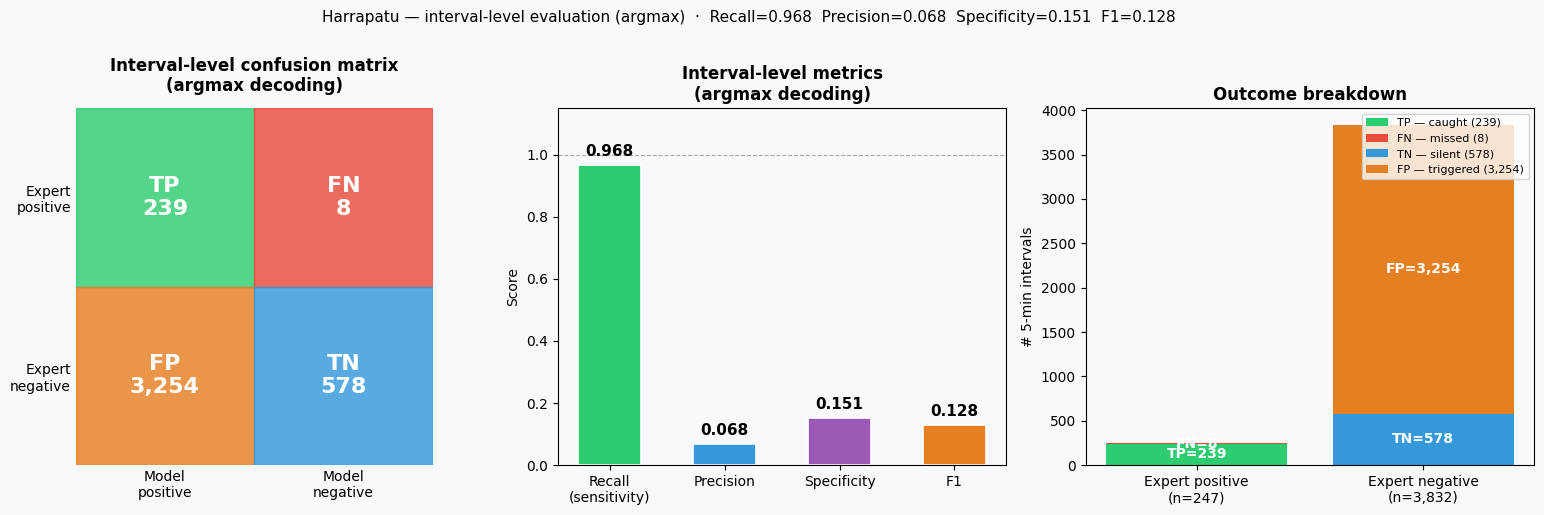

In [10]:
# ── B. Headline confusion matrix ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#f7f9fc')

# ── (1) Confusion matrix tile ─────────────────────────────────────────────────
ax = axes[0]
labels = [['TP', 'FN'], ['FP', 'TN']]
counts = [[TP, FN], [FP, TN]]
colors = [['#2ecc71', '#e74c3c'], ['#e67e22', '#3498db']]
ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.set_aspect('equal')
for r in range(2):
    for c in range(2):
        ax.add_patch(plt.Rectangle([c, 1-r], 1, 1, color=colors[r][c], alpha=0.82))
        ax.text(c+0.5, 1.5-r, f"{labels[r][c]}\n{counts[r][c]:,}",
                ha='center', va='center', fontsize=16, fontweight='bold', color='white')
ax.set_xticks([0.5, 1.5]); ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(['Model\npositive', 'Model\nnegative'], fontsize=10)
ax.set_yticklabels(['Expert\nnegative', 'Expert\npositive'], fontsize=10)
ax.set_title('Interval-level confusion matrix\n(argmax decoding)', fontsize=12, fontweight='bold', pad=12)
ax.tick_params(length=0)
for spine in ax.spines.values(): spine.set_visible(False)

# ── (2) Metric bars ───────────────────────────────────────────────────────────
ax = axes[1]
metrics = {'Recall\n(sensitivity)': recall, 'Precision': precision,
           'Specificity': specificity, 'F1': f1}
mc = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22']
bars = ax.bar(list(metrics), list(metrics.values()), color=mc,
              edgecolor='white', linewidth=1.2, width=0.55)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', fontsize=10)
ax.set_title('Interval-level metrics\n(argmax decoding)', fontsize=12, fontweight='bold')
ax.axhline(1.0, ls='--', lw=0.8, color='#aaa')
for bar, val in zip(bars, metrics.values()):
    lbl = f'{val:.3f}' if not np.isnan(val) else 'n/a'
    ax.text(bar.get_x()+bar.get_width()/2, (val if not np.isnan(val) else 0)+0.02,
            lbl, ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_facecolor('#f7f9fc')

# ── (3) Stacked outcome bars ──────────────────────────────────────────────────
ax = axes[2]
pos_lbl = f'Expert positive\n(n={TP+FN:,})'
neg_lbl = f'Expert negative\n(n={TN+FP:,})'
ax.bar([pos_lbl], [TP],  color='#2ecc71', label=f'TP — caught ({TP:,})')
ax.bar([pos_lbl], [FN],  bottom=[TP], color='#e74c3c', label=f'FN — missed ({FN:,})')
ax.bar([neg_lbl], [TN],  color='#3498db', label=f'TN — silent ({TN:,})')
ax.bar([neg_lbl], [FP],  bottom=[TN], color='#e67e22', label=f'FP — triggered ({FP:,})')
for xpos, bot, val, lbl in [(0, TP/2, TP, f'TP={TP:,}'), (0, TP+FN/2, FN, f'FN={FN:,}'),
                             (1, TN/2, TN, f'TN={TN:,}'), (1, TN+FP/2, FP, f'FP={FP:,}')]:
    if val > 0:
        ax.text(xpos, bot, lbl, ha='center', va='center', color='white', fontweight='bold')
ax.set_ylabel('# 5-min intervals', fontsize=10)
ax.set_title('Outcome breakdown', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.set_facecolor('#f7f9fc')

plt.suptitle(f'Harrapatu — interval-level evaluation (argmax)  ·  '
             f'Recall={recall:.3f}  Precision={precision:.3f}  Specificity={specificity:.3f}  F1={f1:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

Strategy comparison (interval level):
 strategy  TP  FN   FP   TN  recall  precision  specificity    F1
   argmax 239   8 3254  578   0.968      0.068        0.151 0.128
      vec 245   2 3594  238   0.992      0.064        0.062 0.120
       pr 157  90 2507 1325   0.636      0.059        0.346 0.108
consensus 239   8 3254  578   0.968      0.068        0.151 0.128


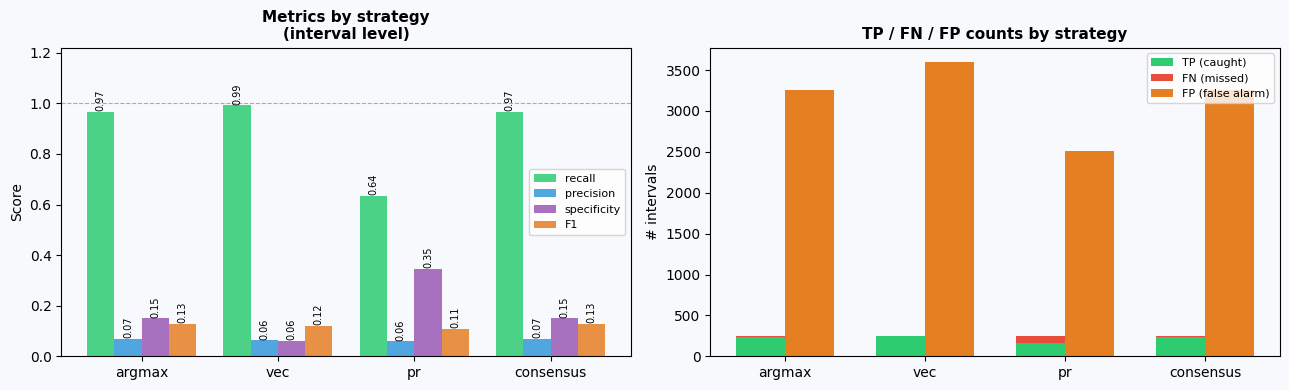

In [11]:
# ── C. Strategy comparison ────────────────────────────────────────────────────
# Compare recall / precision / F1 across the four strategies at interval level.
import matplotlib.pyplot as plt
import numpy as np

strat_rows = []
for s, col in [('argmax','model_pos_argmax'), ('vec','model_pos_vec'),
               ('pr','model_pos_pr'), ('consensus','model_positive')]:
    tp_s = int((ivl['exp_positive'] & ivl[col]).sum())
    fn_s = int((ivl['exp_positive'] & ~ivl[col]).sum())
    fp_s = int((~ivl['exp_positive'] & ivl[col]).sum())
    tn_s = int((~ivl['exp_positive'] & ~ivl[col]).sum())
    rc = tp_s/(tp_s+fn_s) if (tp_s+fn_s) else float('nan')
    pr = tp_s/(tp_s+fp_s) if (tp_s+fp_s) else float('nan')
    sp = tn_s/(tn_s+fp_s) if (tn_s+fp_s) else float('nan')
    f1_s = 2*pr*rc/(pr+rc) if (pr and rc) else float('nan')
    strat_rows.append({'strategy': s, 'TP': tp_s, 'FN': fn_s, 'FP': fp_s, 'TN': tn_s,
                       'recall': rc, 'precision': pr, 'specificity': sp, 'F1': f1_s})

strat_df = pd.DataFrame(strat_rows)
print("Strategy comparison (interval level):")
print(strat_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#f7f9fc')
x = np.arange(len(strat_df)); w = 0.2

ax = axes[0]
for i, (metric, color) in enumerate([('recall','#2ecc71'),('precision','#3498db'),
                                       ('specificity','#9b59b6'),('F1','#e67e22')]):
    bars = ax.bar(x + i*w, strat_df[metric].fillna(0), w, label=metric, color=color, alpha=0.85)
    for bar, val in zip(bars, strat_df[metric]):
        if not np.isnan(val):
            ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.2f}',
                    ha='center', fontsize=7, rotation=90)
ax.set_xticks(x + w*1.5); ax.set_xticklabels(strat_df['strategy'], fontsize=10)
ax.set_ylim(0, 1.22); ax.set_ylabel('Score', fontsize=10)
ax.set_title('Metrics by strategy\n(interval level)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.axhline(1.0, ls='--', lw=0.8, color='#aaa')
ax.set_facecolor('#f7f9fc')

ax = axes[1]
w2 = 0.35
ax.bar(x - w2/2, strat_df['TP'], w2, label='TP (caught)', color='#2ecc71')
ax.bar(x - w2/2, strat_df['FN'], w2, bottom=strat_df['TP'], label='FN (missed)', color='#e74c3c')
ax.bar(x + w2/2, strat_df['FP'], w2, label='FP (false alarm)', color='#e67e22')
ax.set_xticks(x); ax.set_xticklabels(strat_df['strategy'], fontsize=10)
ax.set_ylabel('# intervals', fontsize=10)
ax.set_title('TP / FN / FP counts by strategy', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.set_facecolor('#f7f9fc')

plt.tight_layout(); plt.show()

Species labels in TP intervals (model fired correctly):
model_sp_any
Ambig    143
Tt        16
Oo         9
Gg         3

FN intervals (expert said cetacean, model was silent): 8
  (uncertain segs in FN intervals: 23)

Species labels in FP intervals (model fired, expert found nothing):
model_sp_any
Ambig    2377
Oo        172
Tt        158
Gg         10
Dd          5
Sc          2


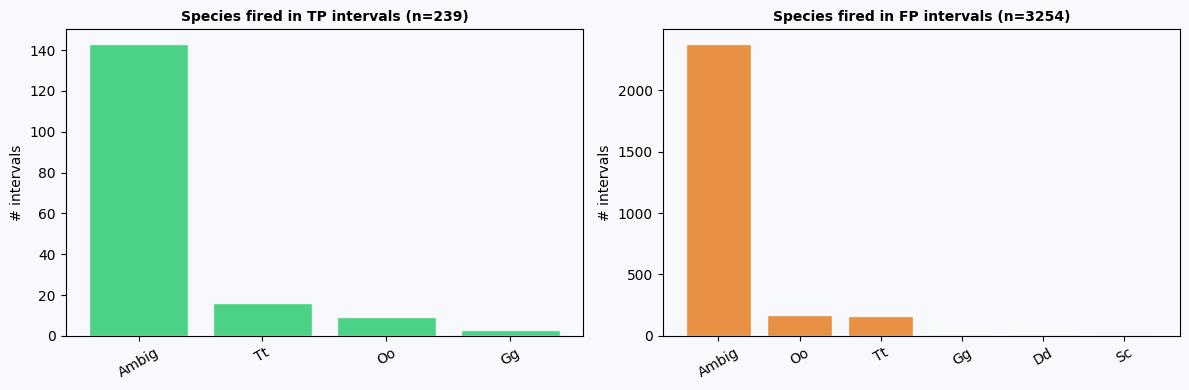

In [12]:
# ── D. Model species breakdown on positive intervals ─────────────────────────
# The expert only labelled T. truncatus, so we can't do a per-species expert
# comparison. But we CAN ask: on expert-positive intervals, which model label
# actually fired (any-segment)? And on FP intervals, which label triggered?
import matplotlib.pyplot as plt

exp_pos = ivl[ivl['exp_positive']].copy()
exp_neg = ivl[~ivl['exp_positive']].copy()

def explode_sp_any(subset):
    sp = subset['model_sp_any'].str.split(', ').explode()
    return sp[sp.str.strip() != ''].value_counts()

tp_sp  = explode_sp_any(exp_pos[exp_pos['model_positive']])   # TP intervals — what fired
fn_sp  = explode_sp_any(exp_pos[~exp_pos['model_positive']])  # FN — nothing fired; no sp
fp_sp  = explode_sp_any(exp_neg[exp_neg['model_positive']])   # FP — what falsely triggered

print("Species labels in TP intervals (model fired correctly):")
print(tp_sp.to_string() if len(tp_sp) else '  (none)')
print(f"\nFN intervals (expert said cetacean, model was silent): {len(exp_pos[~exp_pos['model_positive']]):,}")
print(f"  (uncertain segs in FN intervals: {exp_pos[~exp_pos['model_positive']]['n_uncertain_segs'].sum():,})")
print("\nSpecies labels in FP intervals (model fired, expert found nothing):")
print(fp_sp.to_string() if len(fp_sp) else '  (none)')

if len(tp_sp) + len(fp_sp) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.patch.set_facecolor('#f7f9fc')
    for ax, data, title, color in [
        (axes[0], tp_sp, f'Species fired in TP intervals (n={TP})', '#2ecc71'),
        (axes[1], fp_sp, f'Species fired in FP intervals (n={FP})', '#e67e22'),
    ]:
        if len(data):
            ax.bar(data.index, data.values, color=color, alpha=0.85, edgecolor='white')
            ax.set_title(title, fontsize=10, fontweight='bold')
            ax.set_ylabel('# intervals')
            ax.tick_params(axis='x', rotation=30)
            ax.set_facecolor('#f7f9fc')
        else:
            ax.text(0.5, 0.5, 'none', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title, fontsize=10, fontweight='bold')
    plt.tight_layout(); plt.show()

In [13]:
# ── E. FP / FN deep dive ──────────────────────────────────────────────────────
fp_ivl = ivl[ivl['outcome'] == 'FP'].copy()
fn_ivl = ivl[ivl['outcome'] == 'FN'].copy()

print(f"False positives : {len(fp_ivl):,} expert-negative intervals the model triggered on")
print(f"False negatives : {len(fn_ivl):,} expert-positive intervals the model missed entirely")

print(f"\nFP — segments-per-interval stats (how many segs drove the false alarm):")
print(fp_ivl['n_cetacean_segs'].describe().round(2).to_string())

print(f"\nFN — uncertain segments in missed intervals (strategies partially disagreed):")
print(fn_ivl['n_uncertain_segs'].describe().round(2).to_string())
fn_with_unc = (fn_ivl['n_uncertain_segs'] > 0).sum()
print(f"  FN intervals with ≥1 uncertain seg: {fn_with_unc:,} of {len(fn_ivl):,}")
print("  → these are borderline misses where strategies partially disagreed")

False positives : 3,254 expert-negative intervals the model triggered on
False negatives : 8 expert-positive intervals the model missed entirely

FP — segments-per-interval stats (how many segs drove the false alarm):
count    3254.00
mean       26.19
std        26.08
min         0.00
25%         1.00
50%        21.00
75%        46.00
max        94.00

FN — uncertain segments in missed intervals (strategies partially disagreed):
count    8.00
mean     2.88
std      2.90
min      0.00
25%      0.75
50%      2.00
75%      4.50
max      8.00
  FN intervals with ≥1 uncertain seg: 6 of 8
  → these are borderline misses where strategies partially disagreed


In [14]:
# ── F. Uncertain-segment audit in FN intervals ────────────────────────────────
fn_intervals = set(fn_ivl['interval'])
fn_segs = df_mine[
    df_mine['interval'].isin(fn_intervals) &
    (df_mine['pred_consensus'] == 'uncertain')
].copy()

fn_segs['pattern'] = (
    fn_segs['pred_argmax'] + ' / ' +
    fn_segs['pred_vec']    + ' / ' +
    fn_segs['pred_pr']
)

print(f"Uncertain segments inside FN intervals: {len(fn_segs):,}")
print()
print("Top disagreement patterns (argmax / vec / pr):")
print(fn_segs['pattern'].value_counts().head(15).to_string())

Uncertain segments inside FN intervals: 23

Top disagreement patterns (argmax / vec / pr):
pattern
background / Delphinidae_unknown / background       13
background / Orcinus_orca / background               7
background / Stenella_coeruleoalba / background      2
background / Physeter_macrocephalus / background     1
